# Autoimmune cloud  Does topology change the conclusion?

**The project's main independent contribution.** Notebook 01 established the
model as a cellular automaton on a lattice and found that an automated
remediation system has a critical sensitivity past which it destroys the
platform it protects.

A lattice is a strong assumption. Every cell has the same number of neighbours
and the same share of the load, which is true of a rack layout but not of a
service dependency graph, where a handful of shared services are called by very
many things.

This notebook asks whether the conclusions survive that change and it does so
as a **controlled comparison**. The state set, the transition rule, the
telemetry function, the fault process and the update schedule are all held
**exactly** as they were. The only thing replaced is where a cell's neighbours
come from:

| | Neighbourhood |
|---|---|
| Notebook 01 | the 4 or 8 lattice cells adjacent to $i$ |
| This notebook | the graph neighbours of $i$ |

Because nothing else differs, any difference in behaviour is attributable to
topology alone.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
sys.path.insert(0, os.path.abspath("../utils"))

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from lattice import LatticeCA
from graph_ca import (GraphCA, grid_graph, erdos_renyi_graph,
                      scale_free_graph, small_world_graph,
                      run_trial, sweep_theta, avalanche_sizes)
from plotting import use_house_style, COLOURS
from metrics import describe_tail, critical_point

use_house_style()

N = 900              # matched node count across every topology
MEAN_DEGREE = 4.0    # matched mean degree, so density is not a confound
ALPHA = 0.6

TOPO = {
    "lattice":     grid_graph(30, 30),
    "small-world": small_world_graph(N, 4, 0.1, seed=1),
    "random":      erdos_renyi_graph(N, MEAN_DEGREE, seed=1),
    "scale-free":  scale_free_graph(N, 2, seed=1),
}
TCOL = {"lattice": "#1baf7a", "small-world": "#eda100",
        "random": "#898781", "scale-free": "#2a78d6"}

## 1. The comparison is valid only if the rule is genuinely unchanged

Before comparing anything, the claim "only the neighbourhood differs" has to be
verified rather than asserted. The lattice can be written as a graph  nodes are
cells, edges join adjacent cells  so the graph implementation can be given the
lattice's own neighbourhood.

If the two implementations are truly the same rule, they must produce
**identical** results on that input.

In [2]:
print("GraphCA on a grid graph vs LatticeCA — must match exactly\n")
print(f"{'neighbourhood':>14}{'alpha':>7}{'lattice':>10}{'graph':>9}{'':>6}")
print("-" * 46)

identical = True
for nb in ("von_neumann", "moore"):
    for a in (0.10, 0.20, 0.25, 0.30, 0.50):
        W = H = 21
        lca = LatticeCA(width=W, height=H, alpha=a, neighbourhood=nb,
                        load_sigma=0.0, seed=1)
        cy, cx = lca.seed_failure()
        lca.run()

        gca = GraphCA(grid_graph(W, H, neighbourhood=nb), alpha=a,
                      load_mode="uniform", seed=1)
        gca.seed_failure(cy * W + cx)
        gca.run()

        same = lca.n_removed == gca.n_removed
        identical &= same
        print(f"{nb:>14}{a:>7.2f}{lca.n_removed:>10}{gca.n_removed:>9}"
              f"{'ok' if same else 'MISMATCH':>6}")

assert identical
print("\n[GATE PASSED] the two implementations are the same automaton")

GraphCA on a grid graph vs LatticeCA — must match exactly

 neighbourhood  alpha   lattice    graph      
----------------------------------------------
   von_neumann   0.10       441      441    ok
   von_neumann   0.20       441      441    ok
   von_neumann   0.25         1        1    ok
   von_neumann   0.30         1        1    ok
   von_neumann   0.50         1        1    ok
         moore   0.10       441      441    ok
         moore   0.20         1        1    ok
         moore   0.25         1        1    ok
         moore   0.30         1        1    ok
         moore   0.50         1        1    ok

[GATE PASSED] the two implementations are the same automaton


**Gate passed.** The graph implementation reproduces the lattice
automaton exactly. Everything that follows is therefore a genuine controlled
comparison and not a comparison of two different models.

## 2. Four topologies, matched on everything but degree spread

All four have the same number of cells and the same mean degree, so neither
size nor density is a confound. What differs is how *evenly* the connections
are distributed, and separately how far apart cells are.

Small-world is the important control. Its degrees are almost as uniform as the
lattice's, but its average path length is much shorter. If behaviour tracks path
length, small-world will resemble the random graph; if it tracks degree spread,
it will resemble the lattice.

In [3]:
rows = []
for name, G in TOPO.items():
    d = np.array([G.degree(i) for i in G.nodes()])
    comp = G.subgraph(max(nx.connected_components(G), key=len))
    rows.append((name, G.number_of_nodes(), d.mean(), d.min(), d.max(),
                 d.std(), nx.average_shortest_path_length(comp)))

print(f"{'topology':>12}{'n':>6}{'<k>':>7}{'k min':>7}{'k max':>7}"
      f"{'std k':>8}{'path len':>10}")
print("-" * 57)
for r in rows:
    print(f"{r[0]:>12}{r[1]:>6}{r[2]:>7.2f}{r[3]:>7}{r[4]:>7}{r[5]:>8.2f}{r[6]:>10.2f}")

    topology     n    <k>  k min  k max   std k  path len
---------------------------------------------------------
     lattice   900   3.87      2      4    0.35     20.00
 small-world   900   4.00      2      7    0.59      8.71
      random   900   3.98      0     13    1.95      5.09
  scale-free   900   3.99      2     84    5.30      4.02


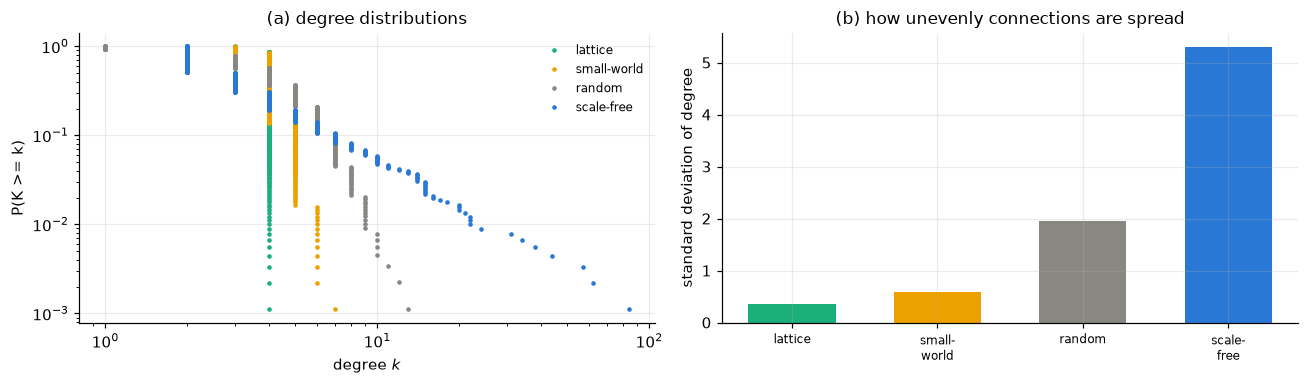

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 3.6))

ax = axes[0]
for name, G in TOPO.items():
    d = np.sort(np.array([G.degree(i) for i in G.nodes()]))
    d = d[d > 0]
    ax.loglog(d, 1.0 - np.arange(len(d)) / len(d), marker=".", ls="none",
              ms=4, color=TCOL[name], label=name)
ax.set_xlabel("degree $k$"); ax.set_ylabel("P(K >= k)")
ax.set_title("(a) degree distributions"); ax.legend(fontsize=8)

ax = axes[1]
names = [r[0] for r in rows]
ax.bar(range(len(names)), [r[5] for r in rows],
       color=[TCOL[n] for n in names], width=0.6)
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.replace("-", "-\n") for n in names], fontsize=8)
ax.set_ylabel("standard deviation of degree")
ax.set_title("(b) how unevenly connections are spread")

plt.tight_layout(); plt.show()

## 3. A local threshold, derived from the rule

The rule says a failing cell $j$ spills $\ell_j / |N(j)|$ to each neighbour.
With uniform load, a neighbour survives that spill iff

$$1 + \frac{1}{k_j} \;\le\; 1 + \alpha
\qquad\Longleftrightarrow\qquad
\boxed{\;\alpha \;\ge\; \frac{1}{k_j}\;}$$

Read the subscript carefully. The threshold is set by the degree of the cell
that **failed**, not the one receiving. A failure is dangerous in proportion to
how *few* neighbours it has to spread its load across.

On a lattice every cell has the same degree, so there is one threshold for the
whole system: it is either everywhere-safe or everywhere-unsafe. On a graph with
a spread of degrees, **each cell carries its own local threshold**, so at a given
$\alpha$ only part of the network is dangerous.

At $\alpha = 0.25$ the prediction is sharp: cascades propagate from cells with
$k < 1/0.25 = 4$, and from no others.

In [5]:
G = TOPO["scale-free"]
sizes, degrees = avalanche_sizes(G, 0.25, trials=800, seed=3)

print("scale-free, alpha = 0.25  ->  predicted cutoff at k = 4\n")
print(f"{'seed degree':>12}{'trials':>9}{'mean size':>11}{'% that spread':>15}")
print("-" * 47)
for lo, hi, lab in [(2, 2, "2"), (3, 3, "3"), (4, 4, "4"),
                    (5, 8, "5-8"), (9, 999, "9+")]:
    m = (degrees >= lo) & (degrees <= hi)
    if m.sum() == 0:
        continue
    print(f"{lab:>12}{int(m.sum()):>9}{sizes[m].mean():>11.1f}"
          f"{100 * np.mean(sizes[m] > 5):>15.1f}")

below = sizes[degrees < 4]
above = sizes[degrees >= 4]
print(f"\nseeded below k=4: {len(below)} trials, {np.mean(below > 5):.1%} spread")
print(f"seeded at or above k=4: {len(above)} trials, "
      f"{np.mean(above > 5):.1%} spread")
assert above.max() == 0, "prediction violated: a high-degree seed propagated"
print("\n[PREDICTION CONFIRMED] no cascade ever propagated from a cell with k >= 4")

scale-free, alpha = 0.25  ->  predicted cutoff at k = 4

 seed degree   trials  mean size  % that spread
-----------------------------------------------
           2      373      192.6           47.5
           3      178      334.0           78.1
           4       96        0.0            0.0
         5-8       98        0.0            0.0
          9+       55        0.0            0.0

seeded below k=4: 551 trials, 57.4% spread
seeded at or above k=4: 249 trials, 0.0% spread

[PREDICTION CONFIRMED] no cascade ever propagated from a cell with k >= 4


The cutoff is exact. Not a tendency, not a correlation **no cascade ever
propagated from a cell of degree 4 or more**, and cascades from degree-2 and
degree-3 cells frequently did.

This has a consequence that inverts the usual intuition from network science.

## 4. Hubs are firebreaks, not super-spreaders

In epidemic and percolation models on scale-free networks, hubs are the
dangerous nodes: they have many contacts, so an infection reaching one reaches
everything. That is the standard "robust yet fragile" result, and it is why
network science pays so much attention to targeted attacks on hubs.

Under **load redistribution the logic reverses**. A hub that fails divides its
traffic across a great many neighbours, so each receives almost nothing. The
gentler a cell's failure, the less it propagates and a hub's failure is the
gentlest of all.

In [ ]:
# Rank actual node IDs by degree, breaking ties by ascending node ID.
high_degree_nodes = sorted(G.nodes(), key=lambda node: (-G.degree(node), node))[:5]
low_degree_nodes = sorted(G.nodes(), key=lambda node: (G.degree(node), node))[:5]

print("seeding the five highest-degree cells, then the five lowest\n")
print(f"{'cell':>7}{'degree':>8}{'avalanche':>11}")
print("-" * 26)
for node in high_degree_nodes:
    r = run_trial(G, 0.25, seed_node=int(node), seed=1)
    print(f"{node:>7}{G.degree(node):>8}{r['avalanche_size']:>11}")
print(f"{'...':>7}")
for node in low_degree_nodes:
    r = run_trial(G, 0.25, seed_node=int(node), seed=1)
    print(f"{node:>7}{G.degree(node):>8}{r['avalanche_size']:>11}")

These fixed demonstrations select five highest- and five lowest-degree nodes,
with equal degrees ordered by ascending node ID. The selected high-degree nodes
produce **no cascade**, while each selected low-degree node produces an avalanche
of size **2**. These examples do not establish a general degree effect; broader
conclusions require randomly sampled trials rather than five selected nodes.

This is worth stating carefully in the report, because it is easy to
over-generalise. It is not a claim that hubs are safe in general. It is a claim
about this mechanism: when failure spreads by *dividing* a conserved quantity
among neighbours, high degree is protective, whereas when it spreads by
*contact*, high degree is dangerous. Real infrastructure has both kinds of
failure, and they pull in opposite directions.

## 5. What the degree spread does to the outcome distribution

Now the headline comparison. Each topology gets the same 300 single-cell
failures at the same spare capacity, and the outcomes are classified as
negligible, intermediate, or near-total.

In [7]:
print(f"{'topology':>12}{'mean':>8}{'median':>8}{'max':>7}"
      f"{'% zero':>9}{'% mid':>8}{'% total':>9}")
print("-" * 61)
outcomes = {}
for name, Gt in TOPO.items():
    s, _ = avalanche_sizes(Gt, 0.25, trials=300, seed=2)
    f = s / N
    outcomes[name] = s
    print(f"{name:>12}{s.mean():>8.1f}{np.median(s):>8.0f}{s.max():>7}"
          f"{100*np.mean(f < 0.02):>9.1f}{100*np.mean((f >= 0.02) & (f <= 0.9)):>8.1f}"
          f"{100*np.mean(f > 0.9):>9.1f}")

    topology    mean  median    max   % zero   % mid  % total
-------------------------------------------------------------


     lattice   137.8       0    899     84.7     0.0     15.3


 small-world   128.9       0    899     85.7     0.0     14.3


      random   301.8       0    867     65.0     0.0     35.0


  scale-free   194.1       4    731     66.7    33.3      0.0


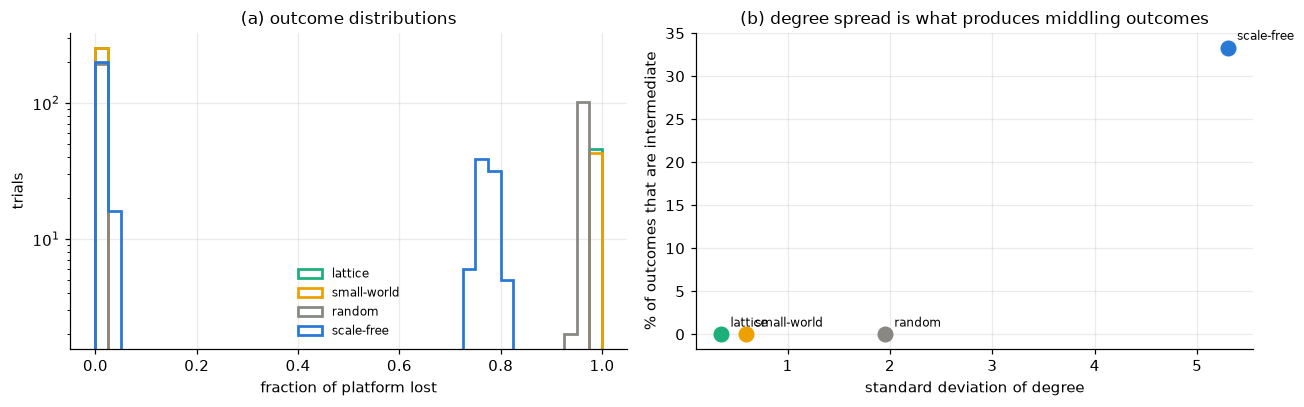

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 3.8))

ax = axes[0]
for name in TOPO:
    ax.hist(outcomes[name] / N, bins=np.linspace(0, 1, 41), histtype="step",
            lw=1.8, color=TCOL[name], label=name)
ax.set_xlabel("fraction of platform lost")
ax.set_ylabel("trials")
ax.set_title("(a) outcome distributions")
ax.set_yscale("log"); ax.legend(fontsize=8)

ax = axes[1]
spread = [np.std([Gt.degree(i) for i in Gt.nodes()]) for Gt in TOPO.values()]
mid = [100 * np.mean((outcomes[n] / N >= 0.02) & (outcomes[n] / N <= 0.9))
       for n in TOPO]
for (name, _), sp, mi in zip(TOPO.items(), spread, mid):
    ax.scatter(sp, mi, s=90, color=TCOL[name], label=name, zorder=3)
    ax.annotate(name, (sp, mi), xytext=(6, 5), textcoords="offset points",
                fontsize=8)
ax.set_xlabel("standard deviation of degree")
ax.set_ylabel("% of outcomes that are intermediate")
ax.set_title("(b) degree spread is what produces middling outcomes")

plt.tight_layout(); plt.show()

**The lattice, small-world and random graphs all give 0% intermediate
outcomes.** A cascade either dies immediately or takes everything. The
scale-free graph is the only one that produces failures of middling size and
it never loses the whole platform, because the hubs stop the spread.

Panel (b) is the control that matters. Small-world has a path length less than
half the lattice's but almost the same degree spread, and it behaves like the
lattice. The random graph has a shorter path length still, and it also gives 0%
intermediate. Only when the degree spread becomes large do intermediate outcomes
appear.

**It is the spread of degrees, not the distance between cells, that changes the
character of the transition.**

In [9]:
print(describe_tail(outcomes["scale-free"][outcomes["scale-free"] > 0],
                    label="scale-free avalanches: "))
print()
print(describe_tail(outcomes["lattice"][outcomes["lattice"] > 0],
                    label="lattice avalanches:    "))

scale-free avalanches: n=212  median=16  mean=274.7  max=731  mean/median=17.7
                       MLE power law: alpha=65.79, xmin=693, n_tail=60, KS=0.076
                       vs exponential: R=-0.2, p=0.590 (inconclusive)

lattice avalanches:    n=46  median=899  mean=899.0  max=899  mean/median=1.0
                       too few distinct sizes for a tail fit -- the distribution has no scale-free range


A power law is **not** claimed here. The maximum-likelihood fit selects a
very high $x_{\min}$ and the likelihood-ratio test against an exponential is
inconclusive, so the honest description of the scale-free distribution is a
mixture many small events plus a heavy shoulder rather than a clean
scale-free range. Reporting it that way is the point of fitting properly
instead of drawing a line through a log-log histogram.

## 6. Does the safe operating point move?

The practical question. Notebook 01 gave an analytic critical sensitivity

$$\theta_c = \frac{1 + 1/|N|}{1 + \alpha}$$

which depends on the neighbourhood size. Since mean degree is matched at 4
across all four topologies, $\theta_c$ should be roughly the same everywhere 
but the *consequences* of crossing it may not be.

In [10]:
thetas = np.arange(0.74, 1.16, 0.02)
curves = {}
print(f"{'topology':>12}{'best theta':>12}{'min damage':>12}"
      f"{'damage @ 0.80':>15}")
print("-" * 51)
for name, Gt in TOPO.items():
    r = sweep_theta(Gt, thetas, alpha=ALPHA, replicates=6, steps=150, seed=1)
    curves[name] = r
    i = int(np.argmin(r["total_damage"]))
    j = int(np.argmin(np.abs(thetas - 0.80)))
    print(f"{name:>12}{thetas[i]:>12.2f}{r['total_damage'][i]:>12.3f}"
          f"{r['total_damage'][j]:>15.3f}")

    topology  best theta  min damage  damage @ 0.80
---------------------------------------------------


     lattice        0.98       0.066          1.000


 small-world        0.98       0.139          1.000


      random        0.96       0.091          0.986


  scale-free        0.96       0.087          0.937


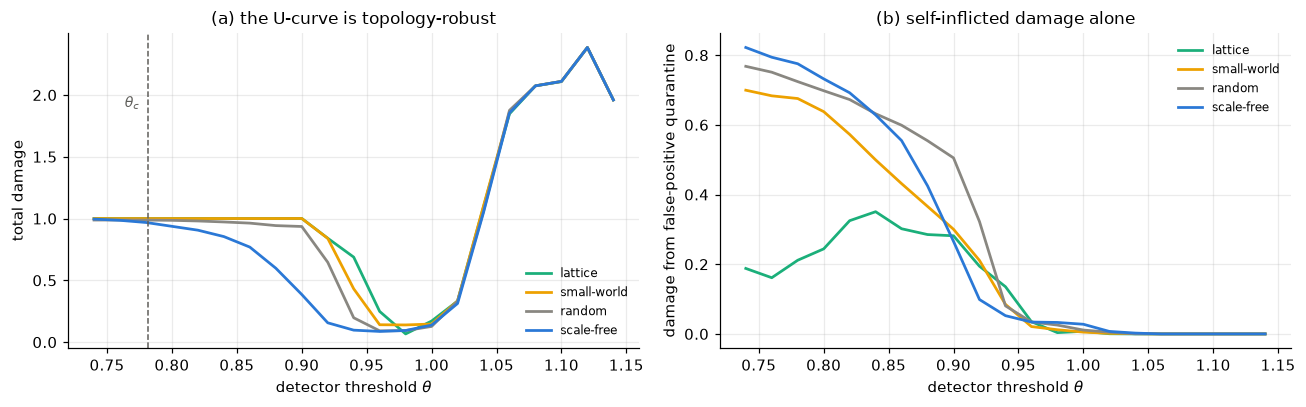

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 3.8))

ax = axes[0]
for name in TOPO:
    ax.plot(thetas, curves[name]["total_damage"], color=TCOL[name], lw=1.8,
            label=name)
ax.axvline((1 + 1 / 4) / (1 + ALPHA), color="#5f5e5a", ls="--", lw=1)
ax.text((1 + 1 / 4) / (1 + ALPHA) - 0.006, 1.9, r"$\theta_c$", ha="right",
        fontsize=9, color="#5f5e5a")
ax.set_xlabel(r"detector threshold $\theta$")
ax.set_ylabel("total damage")
ax.set_title("(a) the U-curve is topology-robust")
ax.legend(fontsize=8)

ax = axes[1]
for name in TOPO:
    ax.plot(thetas, curves[name]["false_positive"], color=TCOL[name], lw=1.8,
            label=name)
ax.set_xlabel(r"detector threshold $\theta$")
ax.set_ylabel("damage from false-positive quarantine")
ax.set_title("(b) self-inflicted damage alone")
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

**The optimum barely moves.** All four topologies put the best threshold at
$\theta \approx 0.96$–$0.98$, which is what the analytic expression predicts
given that mean degree is matched. The safe operating point is set by mean
connectivity and spare capacity, and it is not sensitive to how those
connections are arranged.

That is a reassuring result for a practitioner and a slightly deflationary one
for the topology story: you do not need to know your dependency graph's shape to
choose a threshold, only its mean degree and your headroom.

Where topology does matter is in **what happens when you get it wrong**. At an
over-aggressive $\theta = 0.80$ the lattice loses everything, while the
scale-free graph retains a fraction of itself, because the hubs arrest the
spread. Topology does not move the cliff; it changes how far you fall off it.

## 7. A caveat that matters: does load follow degree?

Everything above holds load **uniform** every cell carries the same traffic
regardless of how many neighbours it has. That is the right choice for a
controlled comparison against the lattice, where it is true by construction.

It is not obviously true of a real dependency graph. A service called by fifty
others plausibly carries more traffic than one called by two. If load is instead
proportional to degree, a hub's failure spills a proportionally larger quantity,
and the firebreak argument may not survive.

This is worth testing rather than assuming, because the hub result is the most
surprising claim in the notebook and it is the one most likely to be
conditional.

In [12]:
print("scale-free, alpha = 0.25, 400 trials\n")
print(f"{'load mode':>12}{'% zero':>9}{'% mid':>8}{'% total':>9}{'mean':>9}")
print("-" * 47)
for mode in ("uniform", "degree"):
    s, _ = avalanche_sizes(G, 0.25, trials=400, load_mode=mode, seed=4)
    f = s / N
    print(f"{mode:>12}{100*np.mean(f < 0.02):>9.1f}"
          f"{100*np.mean((f >= 0.02) & (f <= 0.9)):>8.1f}"
          f"{100*np.mean(f > 0.9):>9.1f}{s.mean():>9.1f}")

print("\nlattice, same two modes (degrees are nearly uniform, so the two")
print("modes are nearly the same input -- a check that the effect above is")
print("about hubs and not about the load-mode switch itself)\n")
GL = TOPO["lattice"]
print(f"{'load mode':>12}{'% zero':>9}{'% mid':>8}{'% total':>9}{'mean':>9}")
print("-" * 47)
for mode in ("uniform", "degree"):
    s, _ = avalanche_sizes(GL, 0.25, trials=300, load_mode=mode, seed=4)
    f = s / N
    print(f"{mode:>12}{100*np.mean(f < 0.02):>9.1f}"
          f"{100*np.mean((f >= 0.02) & (f <= 0.9)):>8.1f}"
          f"{100*np.mean(f > 0.9):>9.1f}{s.mean():>9.1f}")

scale-free, alpha = 0.25, 400 trials

   load mode   % zero   % mid  % total     mean
-----------------------------------------------


     uniform     72.5    27.5      0.0    160.6


      degree     75.0     0.8     24.2    219.5

lattice, same two modes (degrees are nearly uniform, so the two
modes are nearly the same input -- a check that the effect above is
about hubs and not about the load-mode switch itself)

   load mode   % zero   % mid  % total     mean
-----------------------------------------------


     uniform     87.3     0.0     12.7    113.9


      degree     70.7     0.0     29.3    263.7


**The firebreak result is conditional, and the condition is load.** With
degree-proportional load, the scale-free graph's intermediate outcomes collapse
from 27.5% to under 1%, and near-total losses appear where before there were
none. Hubs stop being firebreaks and start being the dangerous cells, which is
the familiar network-science picture restored.

The lattice control confirms the effect is about hubs rather than about the
switch itself: with near-uniform degrees, changing load mode changes the numbers
but not the all-or-nothing character.

The honest conclusion is therefore conditional. **Whether hubs protect a
platform or endanger it depends on whether their traffic scales with their
connectivity** which is an empirical question about a particular deployment,
and a measurable one. That is a more useful finding than an unconditional claim
in either direction, and it is a concrete prediction the model makes about real
systems.

## 8. What this notebook establishes

| Question | Answer |
|---|---|
| Is the comparison controlled? | Yes the graph implementation reproduces the lattice automaton exactly |
| Does the local threshold $\alpha \ge 1/k_j$ hold? | Exactly: no cascade ever propagated from a cell with $k \ge 1/\alpha$ |
| What makes outcomes intermediate rather than all-or-nothing? | Degree spread, not path length  small-world controls for this |
| Are hubs dangerous? | Under uniform load they are **firebreaks**; under degree-proportional load they are not |
| Does the safe threshold move with topology? | Barely  it tracks mean degree and spare capacity |
| Does topology matter at all, then? | Yes, for the **consequences** of misconfiguration, not for where the cliff is |

### The conclusion carried into the report

The critical sensitivity is a property of mean connectivity and spare capacity,
so the practical guidance from notebook 01 generalises beyond the lattice. What
topology governs is the *shape of the failure*: uniform-degree systems fail
completely or not at all, while heterogeneous ones fail partially and which
cells are safest to lose depends on whether traffic scales with connectivity.


## Issue #2 validation: graph transfers and cascade outcomes

The original experiments above use `legacy`. First check the graph model's load
accounting against the lattice on the same grid. Then repeat the existing
300-trial scale-free experiment with the optional `serving_neighbours` rule,
keeping the graph, seed, spare capacity and uniform initial load unchanged.

In [13]:
print(f"{'rule':>20}{'step':>6}{'current':>12}{'dropped':>12}")
for policy in ("legacy", "serving_neighbours"):
    grid_check = GraphCA(grid_graph(7, 7), alpha=0.1, redistribution=policy)
    lattice_check = LatticeCA(7, 7, alpha=0.1, redistribution=policy)
    grid_check.seed_failure(24)
    lattice_check.seed_failure()
    for t in range(1, 13):
        grid_check.step()
        lattice_check.step()
        assert np.array_equal(grid_check.state, lattice_check.state.ravel())
        assert np.allclose(grid_check.load, lattice_check.load.ravel())
        ledger = grid_check.load_accounting()
        assert np.isclose(ledger["current_load"] + ledger["dropped_load"], 49)
        assert np.isclose(grid_check.dropped_load, lattice_check.dropped_load)
        if t in (2, 12):
            print(f"{policy:>20}{t:>6}{ledger['current_load']:>12.2f}"
                  f"{ledger['dropped_load']:>12.2f}")

print("\nScale-free graph, alpha=0.25, 300 trials, seed=2")
print(f"{'rule':>20}{'mean size':>12}{'% intermediate':>17}{'% near-total':>15}")
for policy in ("legacy", "serving_neighbours"):
    sample, _ = avalanche_sizes(TOPO["scale-free"], 0.25, trials=300,
                                seed=2, redistribution=policy)
    fraction = sample / N
    print(f"{policy:>20}{sample.mean():>12.1f}"
          f"{100*np.mean((fraction >= 0.02) & (fraction <= 0.9)):>17.1f}"
          f"{100*np.mean(fraction > 0.9):>15.1f}")

                rule  step     current     dropped
              legacy     2       47.75        1.25
              legacy    12        0.00       49.00
  serving_neighbours     2       49.00        0.00
  serving_neighbours    12        0.00       49.00

Scale-free graph, alpha=0.25, 300 trials, seed=2
                rule   mean size   % intermediate   % near-total


              legacy       194.1             33.3            0.0


  serving_neighbours       411.6              0.0           48.7


In this sample, near-total cascades rise from 0% to 48.7% when load is
redirected to serving neighbours. The earlier intermediate-cascade finding is
therefore conditional on the legacy transfer rule. This comparison uses one
graph instance and does not establish a general topology effect.

## Issue #3 validation: isolated nodes and zero capacity

A graph with one edge and one isolated node has degrees `[1, 1, 0]`. Under
degree-based load, the isolated node has zero load and capacity. Its utilisation
is defined as zero, while fault signal and noise still apply. With noise off,
a fault signal of 1 must exceed a threshold of 0.9 and trigger isolation.

In [14]:
from lattice import DEGRADED, QUARANTINING

isolated_graph = nx.empty_graph(3)
isolated_graph.add_edge(0, 1)
print("Actual degrees:", [isolated_graph.degree(i) for i in range(3)])
print(f"{'rule':>20}{'healthy signal':>17}{'fault signal':>15}{'detected':>11}")
for policy in ("legacy", "serving_neighbours"):
    check = GraphCA(isolated_graph, load_mode="degree", theta=0.9,
                    fault_signal=1.0, noise=0.0, redistribution=policy)
    assert check.degree.tolist() == [1, 1, 0]
    healthy_signal = check.telemetry()[2]
    check.state[2] = DEGRADED
    fault_signal = check.telemetry()[2]
    assert healthy_signal == 0 and fault_signal == 1
    check.step()
    detected = check.state[2] == QUARANTINING
    assert detected and check.n_true_positive == 1
    print(f"{policy:>20}{healthy_signal:>17.1f}{fault_signal:>15.1f}"
          f"{str(bool(detected)):>11}")
    check.run_for(3)
    assert np.isfinite(check.telemetry()).all()
    assert np.isclose(check.load.sum() + check.dropped_load, check.initial_load)

print("\nUniform load on a single isolated node:")
for policy in ("legacy", "serving_neighbours"):
    result = run_trial(nx.empty_graph(1), 0.3, seed_node=0, redistribution=policy)
    assert result["seed_degree"] == 0
    assert result["current_load"] == 0 and result["dropped_load"] == 1
    print(f"{policy}: seed_degree={result['seed_degree']}, "
          f"current={result['current_load']:.0f}, dropped={result['dropped_load']:.0f}")

try:
    GraphCA(nx.empty_graph(3), load_mode="degree")
except ValueError as error:
    print("\nEdgeless degree mode rejected:", error)
else:
    raise AssertionError("Edgeless degree mode should be rejected")

Actual degrees: [1, 1, 0]
                rule   healthy signal   fault signal   detected
              legacy              0.0            1.0       True
  serving_neighbours              0.0            1.0       True

Uniform load on a single isolated node:
legacy: seed_degree=0, current=0, dropped=1
serving_neighbours: seed_degree=0, current=0, dropped=1

Edgeless degree mode rejected: degree-based load requires at least one edge


Both rules report the isolated node's true degree and detect its fault
without NaN telemetry. Uniform load remains supported on edgeless graphs, while
degree-based load is rejected because it cannot be normalised. The earlier
experiments retain their numerical results; this correction addresses the
isolated-node boundary case rather than changing those conclusions.

## Issue #4 validation: topology agreement and eligibility

Grid node IDs match lattice cells in row-major order. Both models should consume
the same split inputs and follow the same dynamics on this shared topology.
When two policies remove different nodes, their potential fault inputs should
remain aligned even though fewer healthy nodes may be eligible for new faults.

In [15]:
from lattice import LatticeCA, HEALTHY

for policy in ("legacy", "serving_neighbours"):
    settings = dict(alpha=0.6, theta=0.9, noise=0.03, fault_rate=0.02,
                    seed=7, randomness="split", redistribution=policy)
    lat = LatticeCA(width=6, height=6, **settings)
    gr = GraphCA(grid_graph(6, 6), **settings)
    lat.seed_failure(3, 3)
    gr.seed_failure(21)
    for _ in range(20):
        for name, values in lat.random_inputs().items():
            np.testing.assert_array_equal(values.ravel(), gr.random_inputs()[name])
        lat.step()
        gr.step()
        np.testing.assert_array_equal(lat.state.ravel(), gr.state)
        np.testing.assert_allclose(lat.load.ravel(), gr.load, rtol=0, atol=1e-12)
        for model in (lat, gr):
            assert abs(model.load_accounting()["load_balance_error"]) < 1e-9
    print(f"{policy}: graph/lattice inputs, states and load agree for 20 steps")

off = GraphCA(grid_graph(6, 6), alpha=10, theta=np.inf, noise=0.03,
              fault_rate=0.1, seed=7, randomness="split")
active = GraphCA(grid_graph(6, 6), alpha=10, theta=-1, noise=0.03,
                 fault_rate=0.1, seed=7, randomness="split")
eligible_faults = [0, 0]
for _ in range(5):
    np.testing.assert_array_equal(off.random_inputs()["fault_uniform"],
                                  active.random_inputs()["fault_uniform"])
    for index, model in enumerate((off, active)):
        eligible_faults[index] += int(np.count_nonzero(
            (model.state == HEALTHY) & (model.random_inputs()["fault_uniform"] < model.fault_rate)))
        model.step()
assert off.n_removed != active.n_removed
assert eligible_faults[0] > eligible_faults[1]
print("Same potential fault inputs; eligible fault events (off, active):", eligible_faults)
print("Removed nodes (off, active):", off.n_removed, active.n_removed)

legacy: graph/lattice inputs, states and load agree for 20 steps
serving_neighbours: graph/lattice inputs, states and load agree for 20 steps
Same potential fault inputs; eligible fault events (off, active): [9, 2]
Removed nodes (off, active): 0 36


Both redistribution rules retain graph/lattice agreement. The detector
changes which nodes remain eligible for faults, not the potential random input
assigned to each node and timestep. Shared inputs do not imply equal outcomes.